<a href="https://colab.research.google.com/github/suryanshshah2006/object-detection-distance-estimation-bdd100k/blob/main/object_detection_distance_estimation_bdd100k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00


In [2]:
import json, os

kaggle_username = 'suryanshshah'
kaggle_token    = 'Insert your token'

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": kaggle_username, "key": kaggle_token}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle authentication successful!")

!kaggle datasets download -d solesensei/solesensei_bdd100k
!unzip -q solesensei_bdd100k.zip -d bdd100k_raw
print("Dataset ready.")

Kaggle authentication successful!
Dataset URL: https://www.kaggle.com/datasets/solesensei/solesensei_bdd100k
License(s): other
100% 7.61G/7.61G [01:00<00:00, 136MB/s]

Dataset ready.


In [8]:
import json, os, glob, shutil, random
from tqdm import tqdm

yolo_base = '/content/yolo_dataset'

for split in ['train', 'val']:
    os.makedirs(f'{yolo_base}/images/{split}', exist_ok=True)
    os.makedirs(f'{yolo_base}/labels/{split}', exist_ok=True)

TARGET_CLASSES = {'traffic sign': 0, 'car': 1, 'truck': 1, 'bus': 1}
IMG_W, IMG_H = 1280.0, 720.0

raw_train_json = glob.glob('/content/bdd100k_raw/**/*train.json', recursive=True)[0]
raw_val_json   = glob.glob('/content/bdd100k_raw/**/*val.json',   recursive=True)[0]

def generate_labels(json_path, label_dir):
    with open(json_path, 'r') as f:
        data = json.load(f)
    for item in tqdm(data, desc=f"Labels {os.path.basename(json_path)}"):
        txt_path    = os.path.join(label_dir, item['name'].replace('.jpg', '.txt'))
        annotations = []
        if 'labels' in item:
            for label in item['labels']:
                cat = label.get('category')
                if cat not in TARGET_CLASSES or 'box2d' not in label:
                    continue
                cls_id = TARGET_CLASSES[cat]
                x1, y1 = label['box2d']['x1'], label['box2d']['y1']
                x2, y2 = label['box2d']['x2'], label['box2d']['y2']
                x1, x2 = max(0, x1), min(IMG_W, x2)
                y1, y2 = max(0, y1), min(IMG_H, y2)
                w = (x2 - x1) / IMG_W
                h = (y2 - y1) / IMG_H
                if w <= 0 or h <= 0:
                    continue
                x_c = ((x1 + x2) / 2) / IMG_W
                y_c = ((y1 + y2) / 2) / IMG_H
                annotations.append(f"{cls_id} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")
        if annotations:
            with open(txt_path, 'w') as f:
                f.write('\n'.join(annotations))

generate_labels(raw_train_json, f'{yolo_base}/labels/train')
generate_labels(raw_val_json,   f'{yolo_base}/labels/val')
print(f"Labels — Train: {len(os.listdir(f'{yolo_base}/labels/train')):,} | Val: {len(os.listdir(f'{yolo_base}/labels/val')):,}")

all_train_imgs = glob.glob('/content/bdd100k_raw/bdd100k/bdd100k/images/100k/train/**/*.jpg', recursive=True)
all_val_imgs   = glob.glob('/content/bdd100k_raw/bdd100k/bdd100k/images/100k/val/**/*.jpg',   recursive=True)
train_lookup   = {os.path.basename(p): p for p in all_train_imgs}
val_lookup     = {os.path.basename(p): p for p in all_val_imgs}
print(f"Images found — Train: {len(train_lookup):,} | Val: {len(val_lookup):,}")

def sync_subset(label_dir, lookup, target_dir, max_images):
    labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    random.shuffle(labels)
    labels = labels[:max_images]
    copied = 0
    for lf in tqdm(labels, desc=f"Syncing {os.path.basename(target_dir)}"):
        img_name = lf.replace('.txt', '.jpg')
        tgt = os.path.join(target_dir, img_name)
        if img_name in lookup and not os.path.exists(tgt):
            shutil.copy(lookup[img_name], tgt)
            copied += 1
    print(f"  Copied: {copied:,}")

sync_subset(f'{yolo_base}/labels/train', train_lookup, f'{yolo_base}/images/train', max_images=5000)
sync_subset(f'{yolo_base}/labels/val',   val_lookup,   f'{yolo_base}/images/val',   max_images=2000)

n_train = len(os.listdir(f'{yolo_base}/images/train'))
n_val   = len(os.listdir(f'{yolo_base}/images/val'))
print(f"\nFinal — Train: {n_train:,} | Val: {n_val:,}")
assert n_train > 0, "Train still empty!"
assert n_val   > 0, "Val still empty!"
print("✅ Ready for training.")

Labels bdd100k_labels_images_val.json: 100%|██████████| 10000/10000 [00:01<00:00, 6331.42it/s]


Labels — Train: 69,822 | Val: 9,993
Images found — Train: 70,000 | Val: 10,000


Syncing train: 100%|██████████| 5000/5000 [00:09<00:00, 522.99it/s]


  Copied: 5,000


Syncing val: 100%|██████████| 2000/2000 [00:03<00:00, 601.35it/s]

  Copied: 2,000

Final — Train: 5,000 | Val: 2,000
✅ Ready for training.


In [9]:
import os, glob

print("=== ZIP FILES ===")
for f in glob.glob('/content/*.zip'):
    size = os.path.getsize(f) / 1e9
    print(f"  {f}  ({size:.2f} GB)")

print("\n=== ALL IMAGE FOLDERS ===")
for d in glob.glob('/content/bdd100k_raw/**/', recursive=True):
    try:
        files = [f for f in os.listdir(d) if f.endswith('.jpg')]
        if len(files) > 0:
            print(f"  {len(files):>7,}  {d}")
    except:
        pass

print("\n=== DISK SPACE ===")
import shutil
total, used, free = shutil.disk_usage('/content')
print(f"  Total: {total/1e9:.1f} GB")
print(f"  Used:  {used/1e9:.1f} GB")
print(f"  Free:  {free/1e9:.1f} GB")

=== ZIP FILES ===
  /content/solesensei_bdd100k.zip  (8.17 GB)

=== ALL IMAGE FOLDERS ===
    1,000  /content/bdd100k_raw/bdd100k_seg/bdd100k/seg/images/val/
    7,000  /content/bdd100k_raw/bdd100k_seg/bdd100k/seg/images/train/
    2,000  /content/bdd100k_raw/bdd100k_seg/bdd100k/seg/images/test/
    1,000  /content/bdd100k_raw/bdd100k/bdd100k/images/10k/val/
    7,000  /content/bdd100k_raw/bdd100k/bdd100k/images/10k/train/
       27  /content/bdd100k_raw/bdd100k/bdd100k/images/10k/test/
       78  /content/bdd100k_raw/bdd100k/bdd100k/images/10k/test/trainB/
      192  /content/bdd100k_raw/bdd100k/bdd100k/images/10k/test/testA/
        5  /content/bdd100k_raw/bdd100k/bdd100k/images/10k/test/testB/
    1,698  /content/bdd100k_raw/bdd100k/bdd100k/images/10k/test/trainA/
   10,000  /content/bdd100k_raw/bdd100k/bdd100k/images/100k/val/
    1,156  /content/bdd100k_raw/bdd100k/bdd100k/images/100k/train/
   24,750  /content/bdd100k_raw/bdd100k/bdd100k/images/100k/train/trainB/
    4,130  /cont

In [10]:
import yaml
from ultralytics import YOLO

data_yaml = {
    'path':  '/content/yolo_dataset',
    'train': 'images/train',
    'val':   'images/val',
    'nc':    2,
    'names': {0: 'traffic sign', 1: 'vehicle'}
}
with open('/content/yolo_dataset/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

model = YOLO('yolov8n.pt')
results = model.train(
    data      = '/content/yolo_dataset/data.yaml',
    epochs    = 20,
    imgsz     = 640,
    batch     = 32,
    patience  = 5,
    optimizer = 'AdamW',
    lr0       = 0.001,
    project   = 'eric_robotics',
    name      = 'nav_detector',
    exist_ok  = True,
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nav_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

Results: /content/runs/detect/eric_robotics/nav_detector

--- Training & Validation Loss / mAP ---


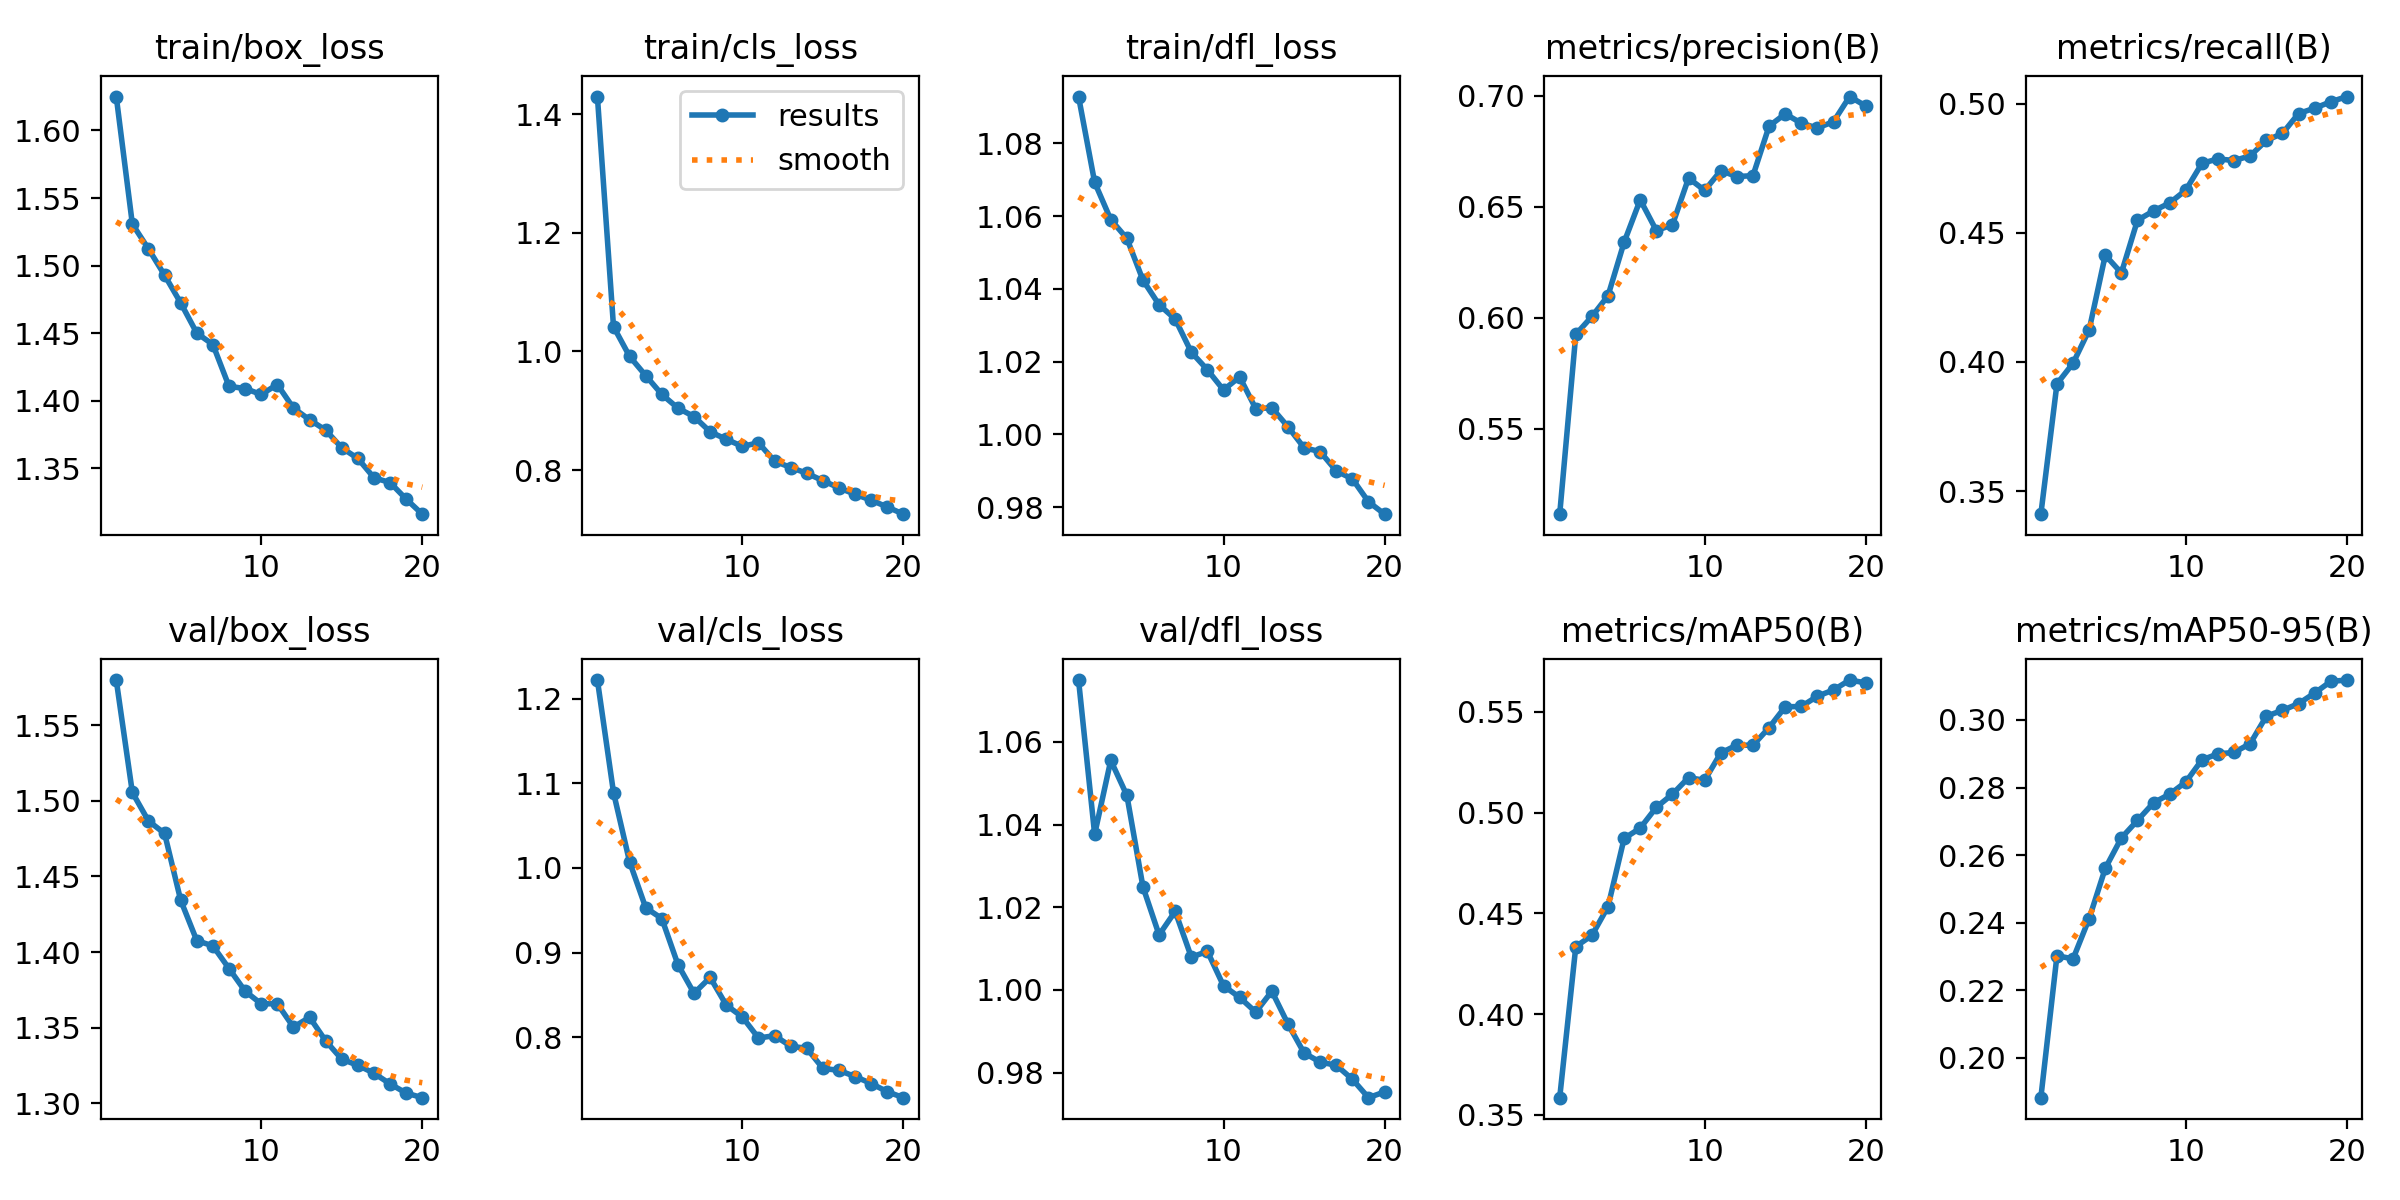

--- Confusion Matrix ---


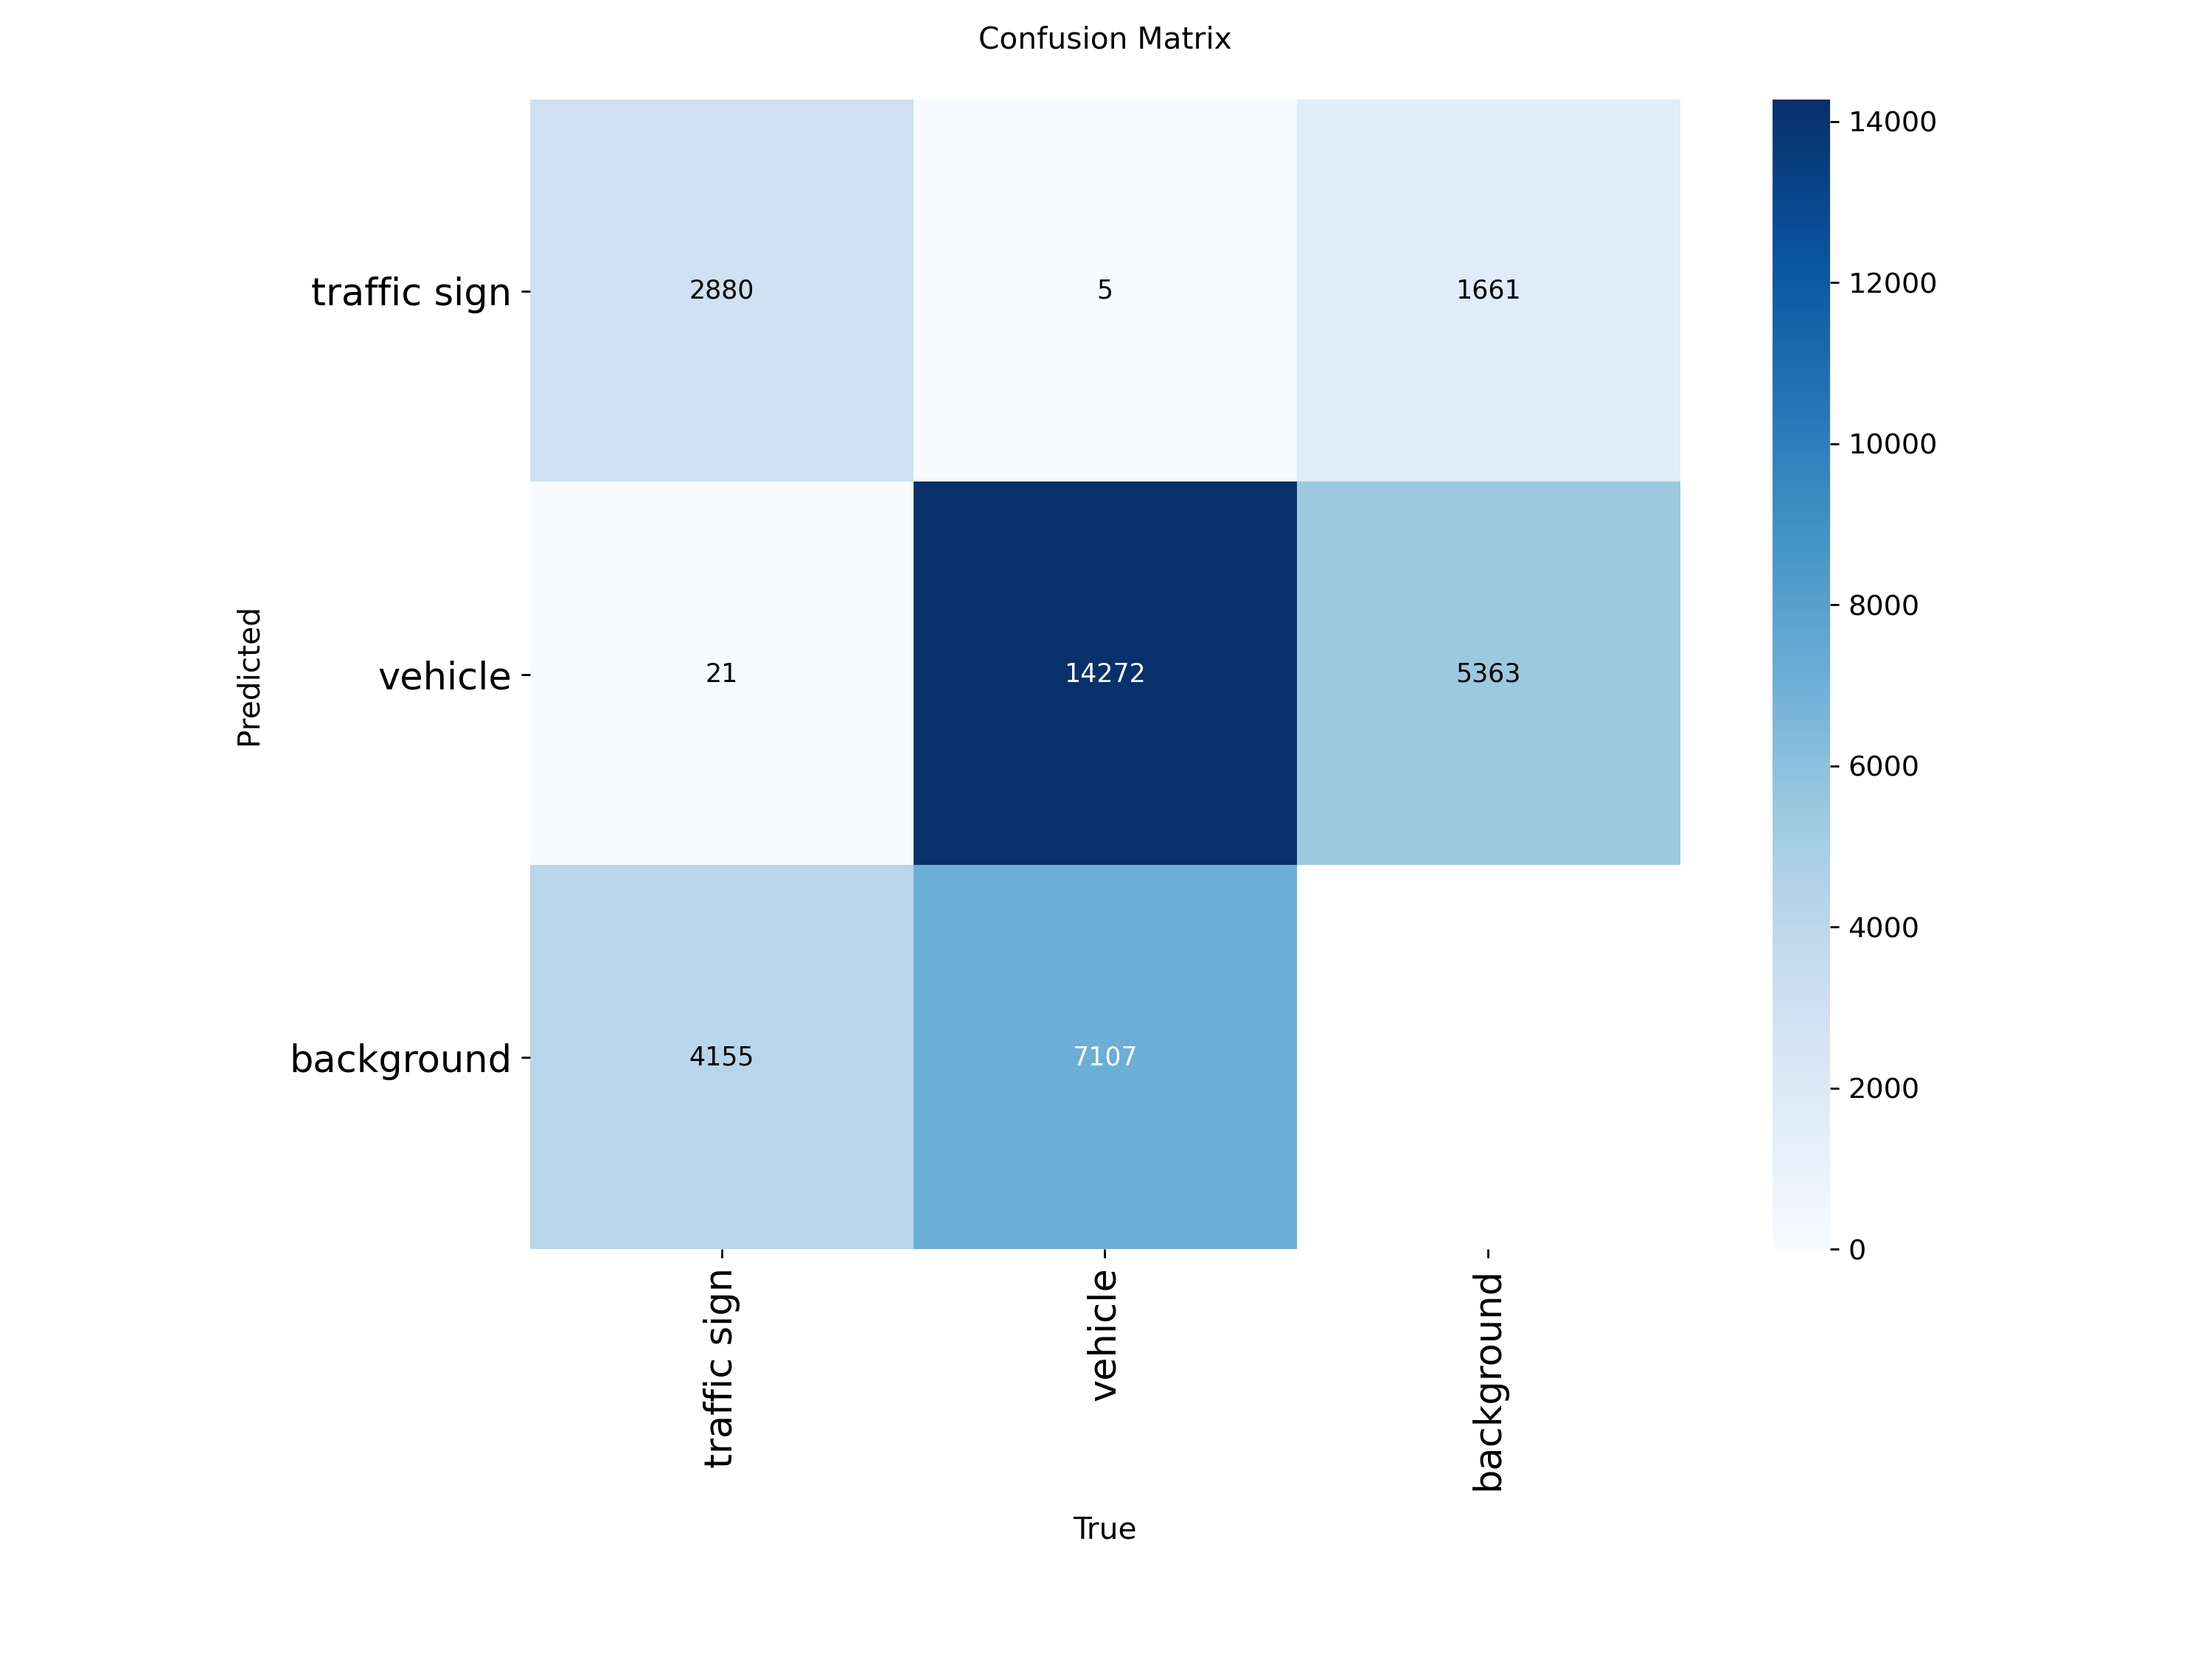

In [16]:
from IPython.display import Image, display

run_dirs   = glob.glob('/content/runs/detect/eric_robotics/*')
latest_run = max(run_dirs, key=os.path.getmtime)
print(f"Results: {latest_run}\n")

for title, fname in [
    ("Training & Validation Loss / mAP", "results.png"),
    ("Confusion Matrix",                  "confusion_matrix.png"),
]:
    path = os.path.join(latest_run, fname)
    print(f"--- {title} ---")
    if os.path.exists(path):
        display(Image(filename=path, width=800 if 'results' in fname else 600))
    else:
        print(f"  [not found: {fname}]")

Using weights: /content/runs/detect/eric_robotics/nav_detector/weights/best.pt

bdb3c90f-ad6c3d26.jpg


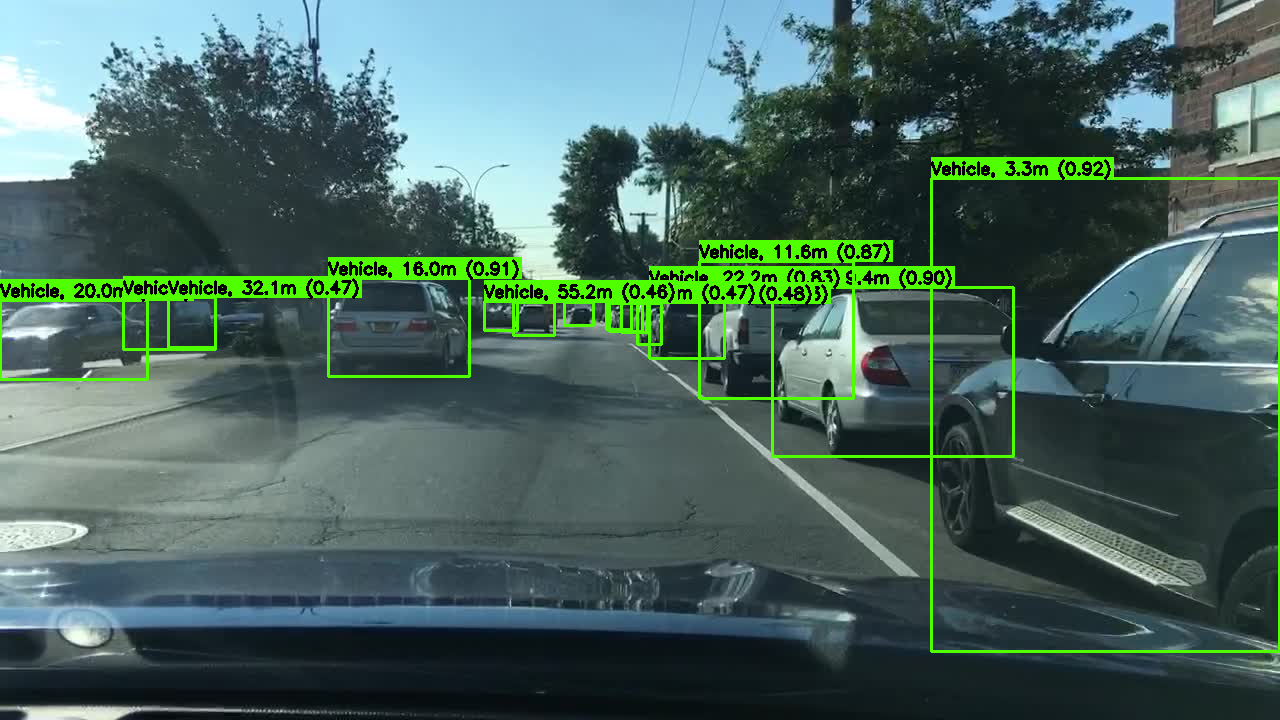


c328b7ab-8bb33358.jpg


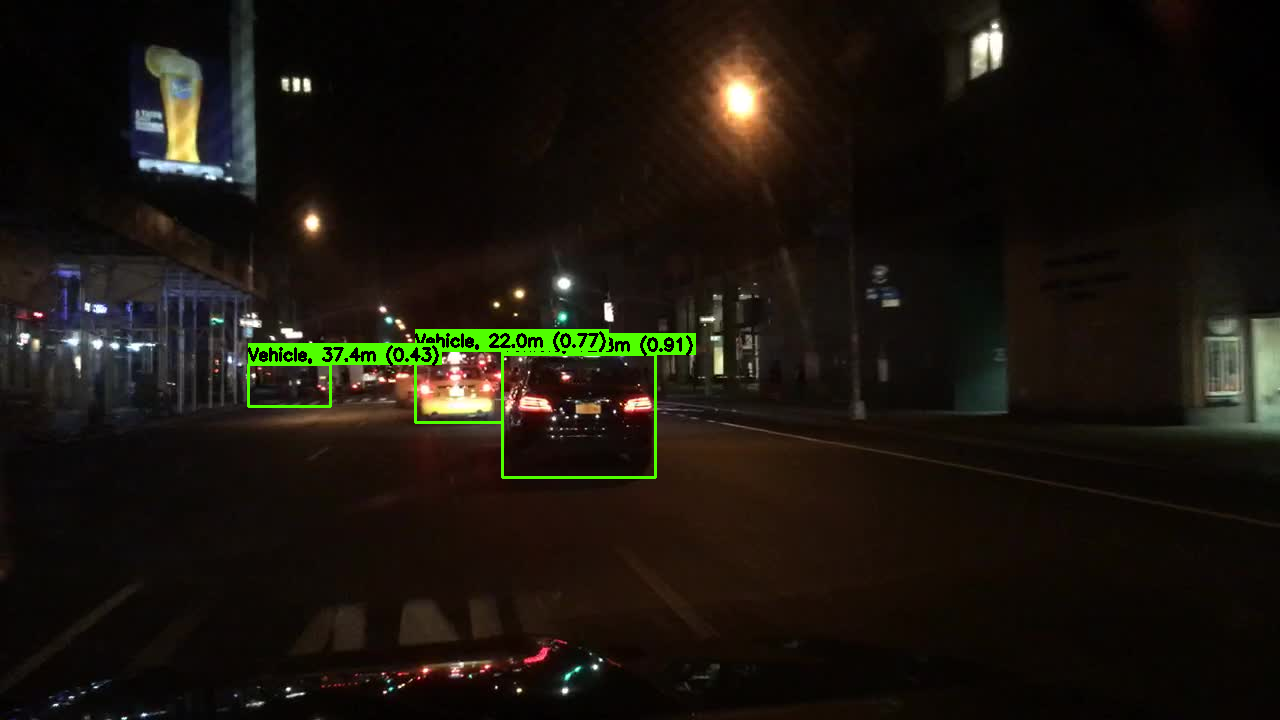


c5588233-76a1ecf3.jpg


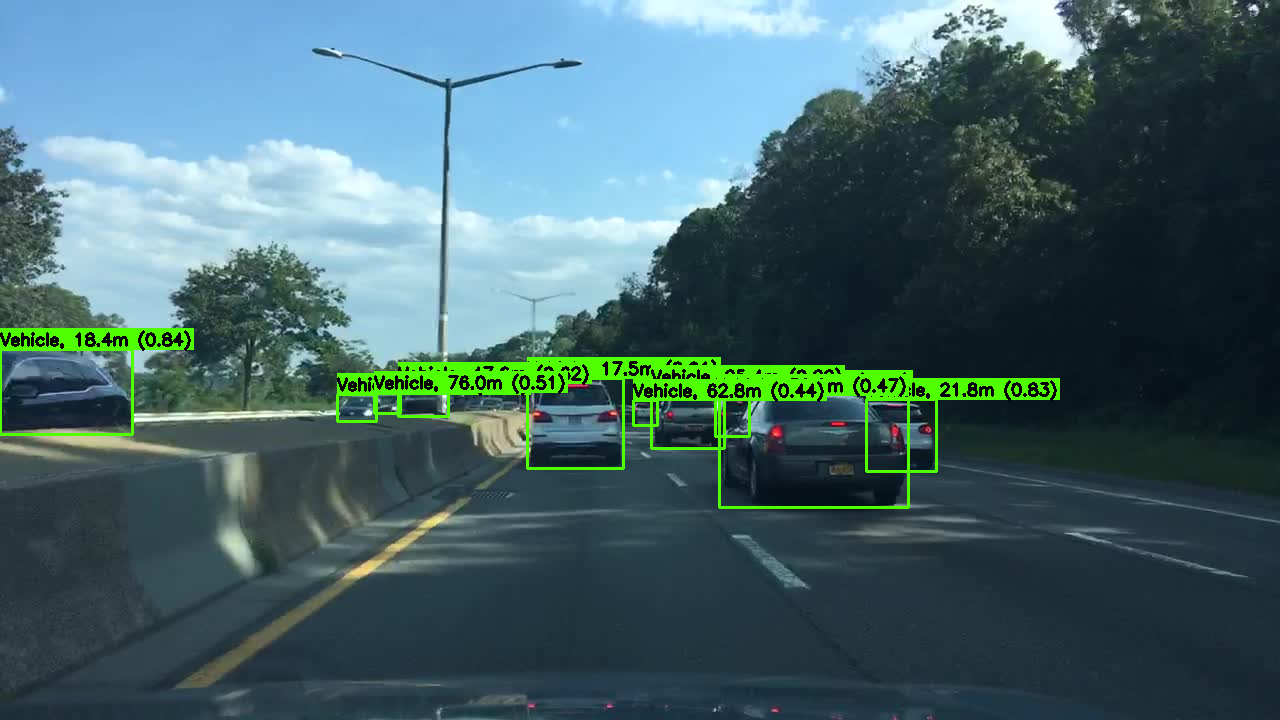

In [13]:
import cv2, random, glob, os
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

weight_files   = glob.glob('/content/runs/detect/eric_robotics/*/weights/best.pt')
latest_weights = max(weight_files, key=os.path.getctime)
print(f"Using weights: {latest_weights}")

FOCAL_LENGTH_PX = 1050.0
REAL_HEIGHTS    = {0: 0.75, 1: 1.50}
CONF_THRESHOLD  = 0.40
CLASS_NAMES     = {0: 'Traffic Sign', 1: 'Vehicle'}   # ← was missing
BOX_COLORS      = {0: (0, 200, 255), 1: (0, 255, 80)}

def estimate_distance(h_px, cls_id):
    if h_px < 5:
        return None
    return (FOCAL_LENGTH_PX * REAL_HEIGHTS[cls_id]) / h_px

def annotate_image(img_path, model):
    img     = cv2.imread(img_path)
    results = model(img, conf=CONF_THRESHOLD, verbose=False)[0]
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0].cpu().numpy())
        conf   = float(box.conf[0].cpu().numpy())
        dist   = estimate_distance(y2 - y1, cls_id)
        color  = BOX_COLORS[cls_id]
        label  = f"{CLASS_NAMES[cls_id]}, {dist:.1f}m ({conf:.2f})" if dist else \
                 f"{CLASS_NAMES[cls_id]} ({conf:.2f})"
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        cv2.rectangle(img, (int(x1), int(y1)-th-8),
                      (int(x1)+tw, int(y1)), color, -1)
        cv2.putText(img, label, (int(x1), int(y1)-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)
    return img

det_model  = YOLO(latest_weights)
val_images = glob.glob('/content/yolo_dataset/images/val/*.jpg')

for img_path in random.sample(val_images, 3):
    print(f"\n{os.path.basename(img_path)}")
    cv2_imshow(annotate_image(img_path, det_model))

In [14]:
import time

model_pt = YOLO(latest_weights)

print("Exporting to ONNX FP16...")
onnx_path  = model_pt.export(format='onnx', half=True)
model_onnx = YOLO(onnx_path)

pt_size   = os.path.getsize(latest_weights) / 1e6
onnx_size = os.path.getsize(onnx_path)      / 1e6
print(f"PyTorch: {pt_size:.1f} MB  →  ONNX FP16: {onnx_size:.1f} MB  "
      f"({(1-onnx_size/pt_size)*100:.1f}% smaller)")

def measure_fps(model, image_folder, device, n=50):
    images = glob.glob(f"{image_folder}/*.jpg")[:n]
    if not images: return 0.0
    dummy = cv2.imread(images[0])
    for _ in range(3):
        model(dummy, device=device, verbose=False)  # warmup
    t0 = time.time()
    for p in images:
        model(cv2.imread(p), device=device, verbose=False)
    return n / (time.time() - t0)

val_dir  = f'{yolo_base}/images/val'
fps_gpu  = measure_fps(model_pt,   val_dir, 'cuda:0')
fps_cpu  = measure_fps(model_pt,   val_dir, 'cpu')
fps_onnx = measure_fps(model_onnx, val_dir, 'cpu')

print("\n╔══════════════════════════════════════════════╗")
print("║         EDGE OPTIMIZATION RESULTS           ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  PyTorch FP32  — GPU (T4):  {fps_gpu:6.2f} FPS       ║")
print(f"║  PyTorch FP32  — CPU:       {fps_cpu:6.2f} FPS       ║")
print(f"║  ONNX FP16     — CPU:       {fps_onnx:6.2f} FPS       ║")
print("╠══════════════════════════════════════════════╣")
print("║  NOTE: x86 CPUs lack native FP16 ALUs,      ║")
print("║  so ONNX FP16 CPU gain is minimal here.     ║")
print("║  On ARM/Jetson: expect 2-3x speedup.        ║")
print("╚══════════════════════════════════════════════╝")

Exporting to ONNX FP16...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/eric_robotics/nav_detector/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 299ms
Prepared 4 packages in 5.64s
Installed 4 packages in 304ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 6.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting e

Optical Flow — motion vectors on detected objects:


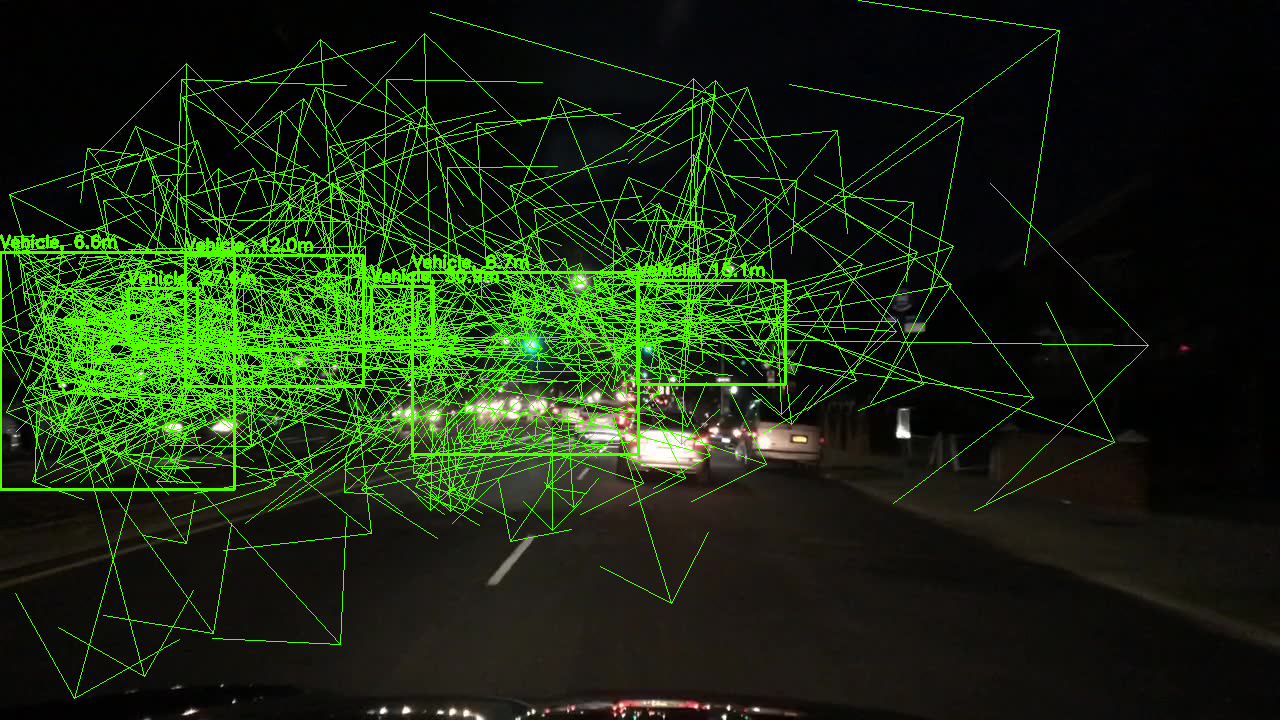

In [15]:
def optical_flow_demo(frame1_path, frame2_path, model):

    f1 = cv2.imread(frame1_path)
    f2 = cv2.imread(frame2_path)
    g1 = cv2.cvtColor(f1, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(f2, cv2.COLOR_BGR2GRAY)

    results = model(f1, conf=CONF_THRESHOLD, verbose=False)[0]
    vis     = f2.copy()

    lk_params = dict(winSize=(15, 15), maxLevel=2,
                     criteria=(cv2.TERM_CRITERIA_EPS |
                               cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    for box in results.boxes:
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
        cls_id = int(box.cls[0].cpu().numpy())

        pts = np.array([[x, y]
                        for x in range(x1+5, x2-5, 15)
                        for y in range(y1+5, y2-5, 15)],
                       dtype=np.float32).reshape(-1, 1, 2)
        if len(pts) == 0:
            continue

        pts2, status, _ = cv2.calcOpticalFlowPyrLK(g1, g2, pts, None, **lk_params)
        good_old = pts[status.flatten()  == 1]
        good_new = pts2[status.flatten() == 1]

        color = BOX_COLORS[cls_id]
        for p_old, p_new in zip(good_old, good_new):
            a, b = p_new.ravel().astype(int)
            c, d = p_old.ravel().astype(int)
            cv2.arrowedLine(vis, (c, d), (a, b), color, 1, tipLength=0.4)

        dist  = estimate_distance(y2 - y1, cls_id)
        label = f"{CLASS_NAMES[cls_id]}, {dist:.1f}m" if dist else CLASS_NAMES[cls_id]
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(vis, label, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return vis

sorted_imgs = sorted(val_images)[:50]
if len(sorted_imgs) >= 2:
    print("Optical Flow — motion vectors on detected objects:")
    cv2_imshow(optical_flow_demo(sorted_imgs[0], sorted_imgs[1], det_model))